In [1]:
from bs4 import BeautifulSoup, Comment
import pandas as pd
import helpers
pd.set_option('display.max_columns', None)

In [2]:
helpers.request_and_save("https://www.basketball-reference.com/players/c/crowdja01.html", "jaecrowder.html")

In [3]:
soup = helpers.parse_for_transactions("jaecrowder.html")


<!DOCTYPE html>

<html class="no-js" data-root="/home/bbr/build" data-version="klecko-" lang="en">
<head>
<meta charset="utf-8"/>
<meta content="ie=edge" http-equiv="x-ua-compatible"/>
<meta content="width=device-width, initial-scale=1.0, maximum-scale=2.0" name="viewport">
<link href="https://cdn.ssref.net/req/202512181" rel="dns-prefetch"/>
<script>
/* https://docs.osano.com/hc/en-us/articles/22469433444372-Google-Consent-Mode-v2  */
  window.dataLayer = window.dataLayer ||[];
      function gtag(){dataLayer.push(arguments);}
      gtag('consent','default',{
        'ad_storage':'denied',
        'analytics_storage':'denied',
        'ad_user_data':'denied',
        'ad_personalization':'denied',
        'personalization_storage':'denied',
        'functionality_storage':'granted',
        'security_storage':'granted',
        'wait_for_update': 500
      });
      gtag("set", "ads_data_redaction", true);
</script>
<script src="https://cmp.osano.com/16CGnCU8UtNhM14sg/12669873-8cf8-4
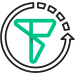
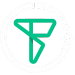

In [4]:
soup

In [5]:
transactions = soup.select_one('#all_transactions')

In [6]:
# Info from: https://stackoverflow.com/questions/52679150/beautifulsoup-extract-text-from-comment-html
def iscomment(element):
    return isinstance(element, Comment)

comments = transactions.find_all(string=iscomment)[0]

In [7]:
commentsoup = BeautifulSoup(comments, "html.parser")
res = commentsoup.text.strip()
res

"June 25, 2009: Traded by the New Orleans Hornets (as a future 2012 2nd round draft pick)  with a 2010 2nd round draft pick (Jarvis Varnado was later selected) to the Miami Heat for Marcus Thornton.\nJuly 10, 2010: Traded by the Miami Heat (as a future 2012 2nd round draft pick)  with a 2011 2nd round draft pick (Milan Mačvan was later selected), a 2013 1st round draft pick (Nemanja Nedović was later selected) and a 2016 1st round draft pick (Timothé Luwawu-Cabarrot was later selected) to the Cleveland Cavaliers for LeBron James. Cleveland also received a trade exception from Miami. Cleveland had the option to swap 1st round draft picks with Miami in 2012 but did not do so.\nJune 28, 2012: Drafted by the Cleveland Cavaliers in the 2nd round (34th pick) of the 2012 NBA Draft.\nJune 29, 2012: Traded by the Cleveland Cavaliers with Jared Cunningham and Bernard James to the Dallas Mavericks for Kelenna Azubuike and Tyler Zeller.\nFebruary 27, 2014: Assigned to the Texas Legends of the G-Le

In [8]:
transaction_list = res.split('\n')

In [9]:
transaction_list

['June 25, 2009: Traded by the New Orleans Hornets (as a future 2012 2nd round draft pick)  with a 2010 2nd round draft pick (Jarvis Varnado was later selected) to the Miami Heat for Marcus Thornton.',
 'July 10, 2010: Traded by the Miami Heat (as a future 2012 2nd round draft pick)  with a 2011 2nd round draft pick (Milan Mačvan was later selected), a 2013 1st round draft pick (Nemanja Nedović was later selected) and a 2016 1st round draft pick (Timothé Luwawu-Cabarrot was later selected) to the Cleveland Cavaliers for LeBron James. Cleveland also received a trade exception from Miami. Cleveland had the option to swap 1st round draft picks with Miami in 2012 but did not do so.',
 'June 28, 2012: Drafted by the Cleveland Cavaliers in the 2nd round (34th pick) of the 2012 NBA Draft.',
 'June 29, 2012: Traded by the Cleveland Cavaliers with Jared Cunningham and Bernard James to the Dallas Mavericks for Kelenna Azubuike and Tyler Zeller.',
 'February 27, 2014: Assigned to the Texas Legend

In [18]:
# Logic to convert transaction_list into a structured DataFrame
# Date is before colon
# If first word is "Signed", then new team is after "with the". Check if the new team is the same as the old team.
# If the first word is "Traded", then the new team is after "to the".
# If the first word is "Waived", then the new team is None.
# If the first word is "Drafted", then the new team is after "by the". Draft number is after "in the (0-9)** round". Draft year is after "of the" or the year in the date.
# If the event starts with "As part of a (0-9)-team trade, traded", then the new team is after the first "to the". Can delete everything after ';' and everything before "traded", then do the normal traded logic.
# If the event starts with "Assigned", then new team is after "to the". Draft number is None. Do not reassign curr_team.
# If the event starts with "Recalled", then the new team is the current team. Draft number is None.

dates = []
event_type = []
new_teams = []
supplementary_info = []
curr_team = ""
for transaction in transaction_list:
    date, event = transaction.split(":", 1)
    print(date)
    if event.strip().startswith("Drafted"):
        dates.append(date.strip())
        event_type.append("Drafted")
        parts = event.strip().split("by the")
        team_part = parts[1].split("in the")[0].strip()
        new_teams.append(team_part)
        info = parts[1].split("in the")[1].strip()
        supplementary_info.append(info)
        curr_team = team_part
    elif event.strip().startswith("Signed"):
        team_part = event.strip().split("with the")[1].split(".")[0].strip()
        if team_part != curr_team:
            dates.append(date.strip())
            event_type.append("Signed")
            team_part = event.strip().split("with the")[1].split(".")[0].strip()
            new_teams.append(team_part)
            supplementary_info.append(None)
            curr_team = team_part
    elif event.strip().startswith("Traded"):
        dates.append(date.strip())
        event_type.append("Traded")
        team_part = event.strip().split("to the")[1].split("for")[0].strip()
        new_teams.append(team_part)
        info = ("with " + event.strip().split("with")[1].split("to the")[0].strip() if len(event.strip().split("with")[1].split("to the")) > 1 else "") + ("for " + event.strip().split("for")[1].strip())
        supplementary_info.append(info)
        curr_team = team_part
    elif event.strip().startswith("Waived"):
        dates.append(date.strip())
        event_type.append("Waived")
        new_teams.append(None)
        supplementary_info.append(None)
    elif event.strip().startswith("As part of a"):
        dates.append(date.strip())
        event_type.append("Traded")
        trade_part = event.strip().split(";")[0]
        team_part = trade_part.split("to the")[1].strip()
        new_teams.append(team_part)
        with_parts = event.strip().split("with")
        info = ("with " + with_parts[1].split("to the")[0].strip() if len(with_parts) > 1 and len(with_parts[1].split("to the")) > 1 else None)
        supplementary_info.append(info)
        curr_team = team_part
    elif event.strip().startswith("Assigned"):
        dates.append(date.strip())
        event_type.append("Assigned")
        team_part = event.strip().split("to the")[1].split('of')[0].strip()
        new_teams.append(team_part)
        supplementary_info.append(curr_team)
    elif event.strip().startswith("Recalled"):
        dates.append(date.strip())
        event_type.append("Recalled")
        new_teams.append(curr_team)
        supplementary_info.append(team_part)
    elif event.strip().startswith("Retired"):
        dates.append(date.strip())
        event_type.append("Retired")
        new_teams.append(None)
        supplementary_info.append('Was with ' + curr_team)

June 25, 2009
July 10, 2010
June 28, 2012
June 29, 2012
February 27, 2014
February 28, 2014
March 1, 2014
March 2, 2014
December 18, 2014
July 27, 2015
August 30, 2017
February 8, 2018
July 6, 2019
February 6, 2020
November 28, 2020
February 9, 2023
July 8, 2023
November 27, 2024


In [39]:
df = pd.DataFrame({
    "Date": dates,
    "Event": event_type,
    "New Team": new_teams,
    "Supplementary Info": supplementary_info
})

In [40]:
df['next'] = df.index + 1
df['next'] = df['next'].apply(lambda x: x if x < len(df) else None)
df = df.reset_index(drop=True)
df

,Date,Event,New Team,Supplementary Info,next
0,"June 25, 2009",Traded,Miami Heat,with a 2010 2nd round draft pick (Jarvis Varna...,1.0
1,"July 10, 2010",Traded,Cleveland Cavaliers,with a 2011 2nd round draft pick (Milan Mačvan...,2.0
2,"June 28, 2012",Drafted,Cleveland Cavaliers,2nd round (34th pick) of the 2012 NBA Draft.,3.0
3,"June 29, 2012",Traded,Dallas Mavericks,with Jared Cunningham and Bernard Jamesfor Kel...,4.0
4,"February 27, 2014",Assigned,Texas Legends,Dallas Mavericks,5.0
5,"February 28, 2014",Recalled,Dallas Mavericks,Texas Legends,6.0
6,"March 1, 2014",Assigned,Texas Legends,Dallas Mavericks,7.0
7,"March 2, 2014",Recalled,Dallas Mavericks,Texas Legends,8.0
8,"December 18, 2014",Traded,Boston Celtics,"with Jameer Nelson, Brandan Wright, a 2016 1st...",9.0
9,"August 30, 2017",Traded,Cleveland Cavaliers,"with Isaiah Thomas, Ante Žižić, a 2018 1st rou...",10.0


In [21]:
import numpy as np
pd.isna(df.loc[3, "next"])

False

In [22]:
# Graph each event with a node, with date and then the event (type, team). Edges should connect each event in chronological order (as arrows).
# --- IGNORE ---
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
G = nx.DiGraph()
for index, row in df.iterrows():
    node_label = f"{row['Date']}\n{row['Event']}\n{row['New Team']}"
    G.add_node(index, attr=node_label)
    if not pd.isna(row['next']):
        G.add_edge(index, row['next'])
# --- IGNORE ---

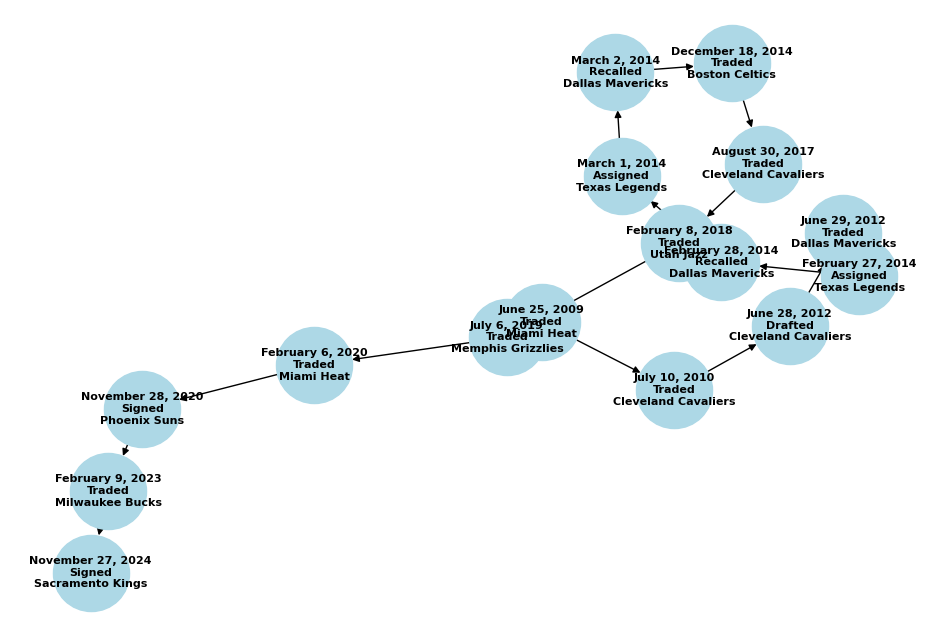

In [23]:
pos = nx.spring_layout(G)
node_labels = nx.get_node_attributes(G, 'attr')
fig, ax = plt.subplots(figsize=(12, 8))
nx.draw(G, pos, ax=ax, with_labels=True, labels=node_labels, node_size=3000, node_color="lightblue", font_size=8, font_weight="bold", arrows=True)

Trying to get table for salary and games

In [24]:
games = soup.select_one('#div_per_game_stats')
gh = games.prettify()
# new line before <thead>
# after 31 <th> or <td>, then new line
print(gh)

<div class="table_container tabbed current" id="div_per_game_stats">
 <table class="stats_table sortable row_summable suppress_headers soc" data-cols-to-freeze="1,3" data-soc-sum-entity-id="crowdja01" data-soc-sum-params="null" data-soc-sum-phase-type="reg" data-soc-sum-scope-type="player_season" data-soc-sum-table-type="PlayerPerGame" id="per_game_stats">
  <caption>
   Per Game Table
  </caption>
  <colgroup>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
  </colgroup>
  <thead>
   <tr>
    <th aria-label="Season" class="poptip center" data-stat="year_id" scope="col">
     Season
    </th>
    <th aria-label="Age" class="poptip center" data-stat="age" data-tip="Player's age on January 31 of the season" scope="col">
     Age
 

In [25]:
columns_soup = games.select_one('thead').select('th')
cols = []
for col in columns_soup:
    cols.append(col.text.strip())

cols

['Season',
 'Age',
 'Team',
 'Lg',
 'Pos',
 'G',
 'GS',
 'MP',
 'FG',
 'FGA',
 'FG%',
 '3P',
 '3PA',
 '3P%',
 '2P',
 '2PA',
 '2P%',
 'eFG%',
 'FT',
 'FTA',
 'FT%',
 'ORB',
 'DRB',
 'TRB',
 'AST',
 'STL',
 'BLK',
 'TOV',
 'PF',
 'PTS',
 'Awards']

In [26]:
table_soup = games.select_one('tbody').select('tr')
data = []
for row in table_soup:
    row_data = []
    for cell in row.select('th, td'):
        row_data.append(cell.text.strip())
    data.append(row_data)
data_df = pd.DataFrame(data, columns=cols)
data_df = data_df[["Season", "G", "GS"]]
data_df

,Season,G,GS
0,2012-13,78,16
1,2013-14,78,8
2,2014-15,82,17
3,2014-15,25,0
4,2014-15,57,17
5,2015-16,73,73
6,2016-17,72,72
7,2017-18,80,47
8,2017-18,53,47
9,2017-18,27,0


In [27]:
salaries = soup.select_one('#all_all_salaries')

In [28]:
comments_salaries = salaries.find_all(string=iscomment)[0]
comment_soup = BeautifulSoup(comments_salaries, "html.parser")
salary_data = []
for row in comment_soup.select_one('tbody').select('tr'):
    row_data = []
    for col in row.select('th, td'):
        row_data.append(col.text.strip())
    salary_data.append(row_data)

salary_df = pd.DataFrame(salary_data, columns=['Year', 'Team', 'League', 'Salary'])
salary_df

,Year,Team,League,Salary
0,2012-13,Dallas Mavericks,NBA,"$600,491"
1,2013-14,Dallas Mavericks,NBA,"$788,872"
2,2014-15,Boston Celtics,NBA,"$915,243"
3,2015-16,Boston Celtics,NBA,"$6,000,000"
4,2016-17,Boston Celtics,NBA,"$6,286,408"
5,2017-18,Utah Jazz,NBA,"$6,796,117"
6,2018-19,Utah Jazz,NBA,"$7,305,825"
7,2019-20,Miami Heat,NBA,"$7,815,533"
8,2020-21,Phoenix Suns,NBA,"$9,258,000"
9,2021-22,Phoenix Suns,NBA,"$9,720,900"


In [29]:
data_df.merge(salary_df, left_on='Season', right_on='Year', how='left')

,Season,G,GS,Year,Team,League,Salary
0,2012-13,78,16,2012-13,Dallas Mavericks,NBA,"$600,491"
1,2013-14,78,8,2013-14,Dallas Mavericks,NBA,"$788,872"
2,2014-15,82,17,2014-15,Boston Celtics,NBA,"$915,243"
3,2014-15,25,0,2014-15,Boston Celtics,NBA,"$915,243"
4,2014-15,57,17,2014-15,Boston Celtics,NBA,"$915,243"
5,2015-16,73,73,2015-16,Boston Celtics,NBA,"$6,000,000"
6,2016-17,72,72,2016-17,Boston Celtics,NBA,"$6,286,408"
7,2017-18,80,47,2017-18,Utah Jazz,NBA,"$6,796,117"
8,2017-18,53,47,2017-18,Utah Jazz,NBA,"$6,796,117"
9,2017-18,27,0,2017-18,Utah Jazz,NBA,"$6,796,117"
